In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score)

In [3]:
df = pd.read_parquet('diabetes_prediction_dataset.parquet')
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [4]:
df.shape

(100000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [8]:
df.duplicated().sum()

np.int64(3854)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


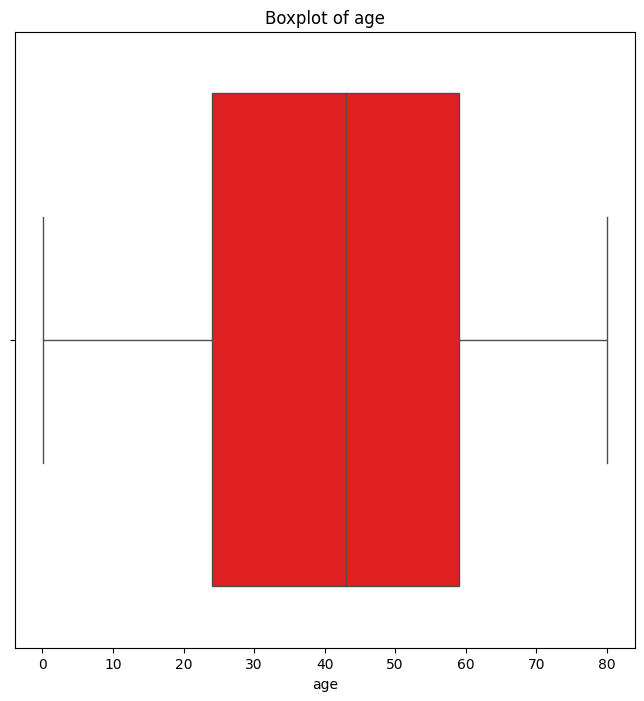

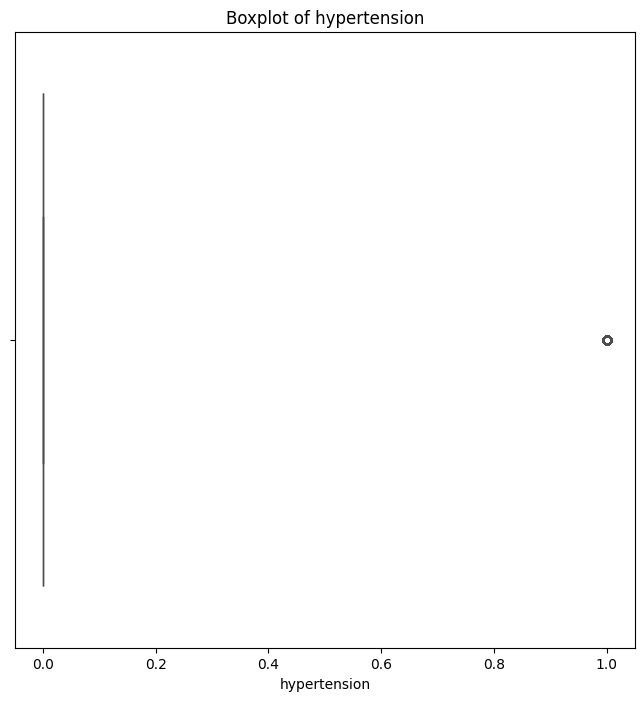

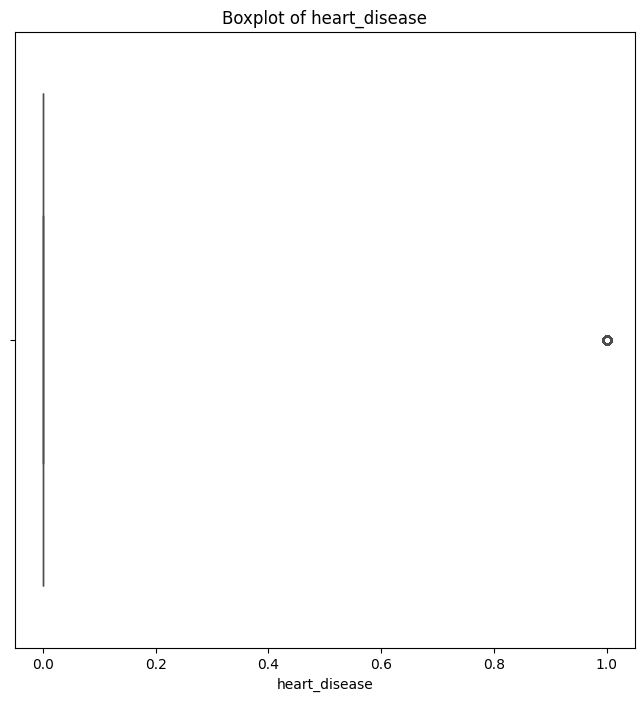

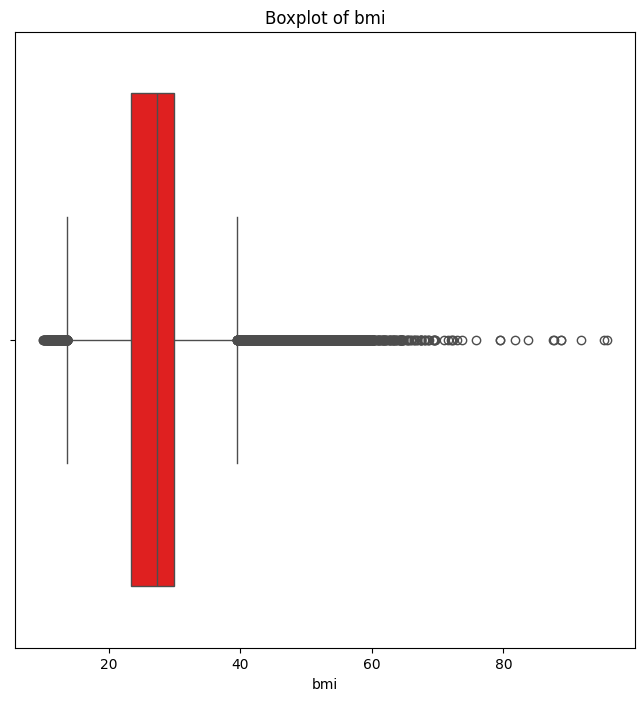

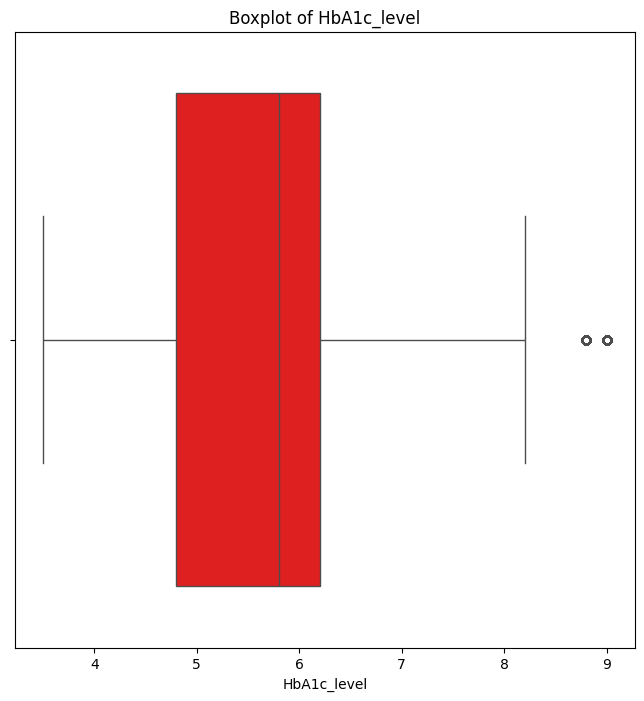

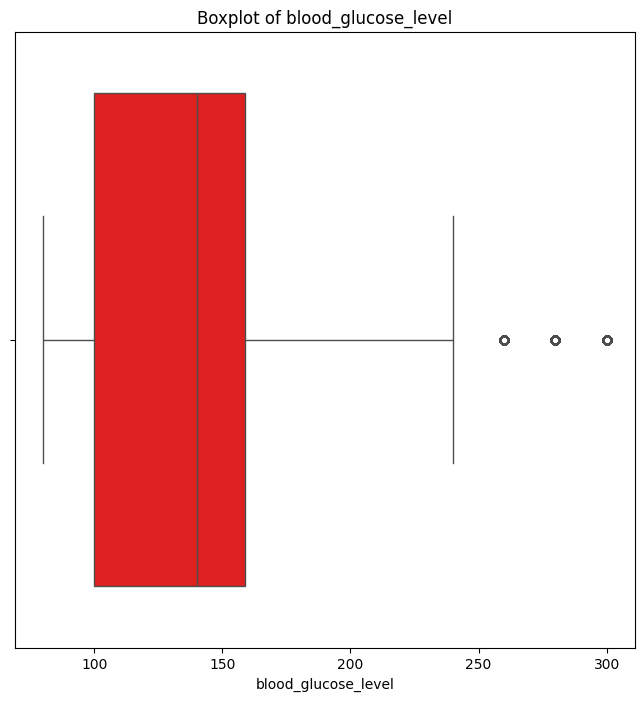

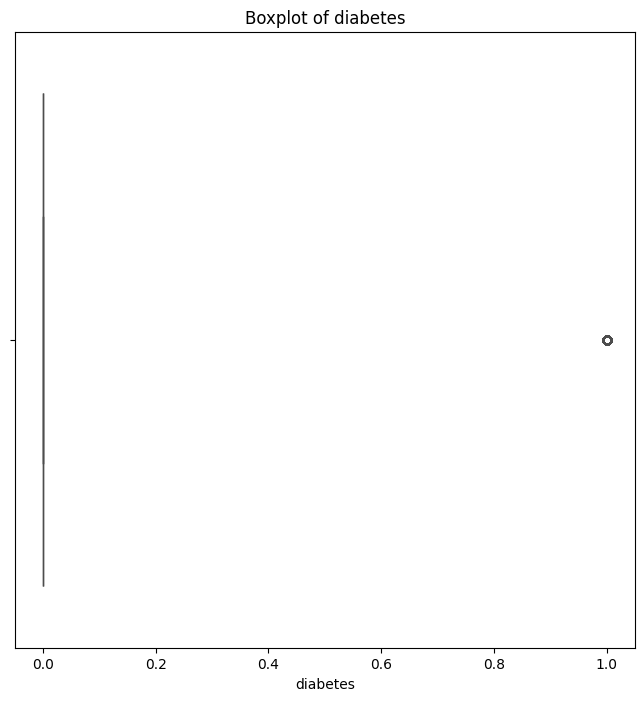

In [13]:
for col in df.select_dtypes(include='number').columns:
  plt.figure(figsize=(8,8))
  sns.boxplot(data = df, x = col,color='red')
  plt.title(f"Boxplot of {col}")
  plt.show()

In [15]:
def whisker(col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - (1.5 * iqr)
  upper_bound = q3 +  (1.5 * iqr)
  return [lower_bound,upper_bound]

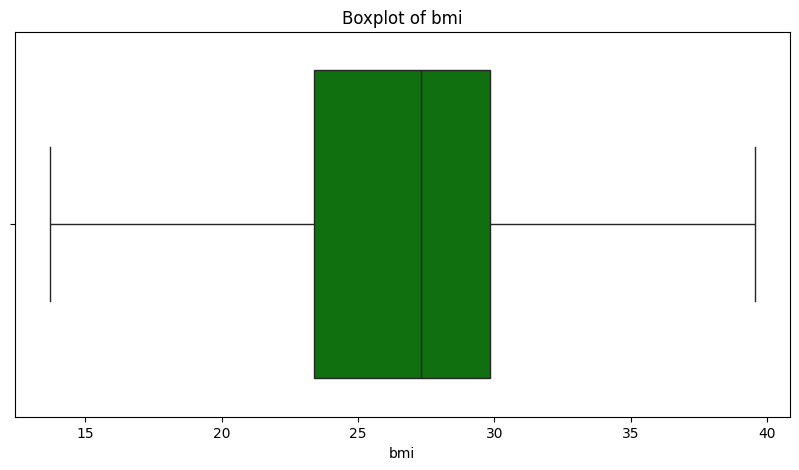

In [16]:
lower_bound, upper_bound =  whisker('bmi')
df['bmi'] = np.where(df['bmi']<lower_bound,lower_bound,df['bmi'])
df['bmi'] = np.where(df['bmi']>upper_bound,upper_bound,df['bmi'])
# verification
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = 'bmi',color = 'green')
plt.title("Boxplot of bmi")
plt.show()


In [37]:
df = pd.get_dummies(df,columns = ['gender','smoking_history'])
df.sample(10)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
80205,41.0,0,0,33.78,6.5,85,0,False,True,False,True,False,False,False,False,False
81042,57.0,0,0,28.90,6.8,155,1,True,False,False,False,False,False,False,True,False
74862,46.0,0,0,23.48,5.0,90,0,False,True,False,True,False,False,False,False,False
12511,35.0,0,0,27.32,3.5,158,0,True,False,False,False,True,False,False,False,False
48982,37.0,0,0,25.12,5.7,130,0,True,False,False,False,False,False,False,False,True
876,35.0,0,0,36.87,6.6,85,0,True,False,False,False,False,False,True,False,False
87917,13.0,0,0,29.60,5.7,130,0,False,True,False,False,False,False,False,True,False
40239,33.0,0,0,39.55,4.8,155,0,True,False,False,False,False,False,False,True,False
48490,30.0,0,0,23.67,6.2,140,0,True,False,False,False,False,False,False,False,True
81121,17.0,0,0,18.39,6.6,90,0,True,False,False,True,False,False,False,False,False


In [31]:
x = df.drop('diabetes',axis=1)
y = df['diabetes']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(x_train,y_train)
model.score(x_test,y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8858554342173687

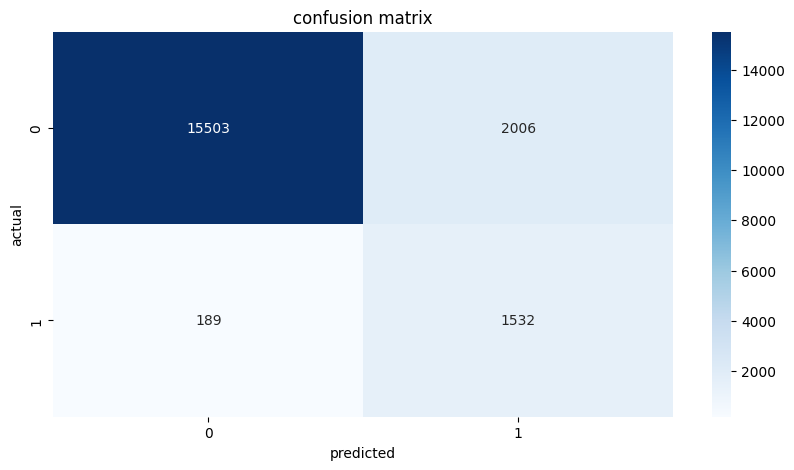

In [32]:
y_pred = model.predict(x_test)
cm  = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17509
           1       0.43      0.89      0.58      1721

    accuracy                           0.89     19230
   macro avg       0.71      0.89      0.76     19230
weighted avg       0.94      0.89      0.90     19230



In [34]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.8858554342173687
0.43301300169587337
0.8901801278326554
0.5826202700133105


In [38]:
model.predict([[57.0,0,0,	28.90,	6.8,	155	,1,	0,	0,	0,	0,	0,	0,	1,	0]]) # correctly - predicted

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])